In [1]:
from src import *
from myutils import *

from scipy.optimize import curve_fit

In [2]:
10 * DMD.PIXEL_SIZE / 0.5

387.49451609022805

In [3]:
400e-6

0.0004

In [4]:
4e-4

0.0004

In [5]:
class v_sim(Simulator):
    def loc(self, n):
        fs = self.sampling_rate
        t = n / fs
        return 400 * t - 5 * DMD.PIXEL_SIZE


In [22]:
def s(t, v, b):
    return v * t + b

In [39]:
def main():
    spade_raw = v_sim(MetaData('DI', 1, 1, 0)).gen(400, sample_length=10)
    # di_raw = v_sim(MetaData('DI', 1, 1, 0)).gen(400, sample_length=10)

    spade_td = td_estimator('DI', spade_raw, spade_method='zhou2023')
    v_est = curve_fit(s, np.arange(10)/20, spade_td, p0=[0, 0])[0][0]
    return v_est

In [40]:
fi11 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**2)
fi12 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**1)
fi22 = 1/(SPADE.SIGMA*20)**2 * np.sum(np.arange(10)**0)
crb = np.linalg.inv(np.array([[fi11, fi12], [fi12, fi22]]))[0, 0]

In [44]:
main() * qCMOS.PIXEL_SIZE

404.31808750196745

In [36]:
lst = np.array([main() for _ in range(200)])
print(lst.var() * 60 / crb)

1.3965771742625706


In [45]:
x, y = [], []
for test in range(100):
    lst = np.array([main() for _ in range(200)])
    x.append(test+1)
    y.append((lst*qCMOS.PIXEL_SIZE).var() * 400 / crb)

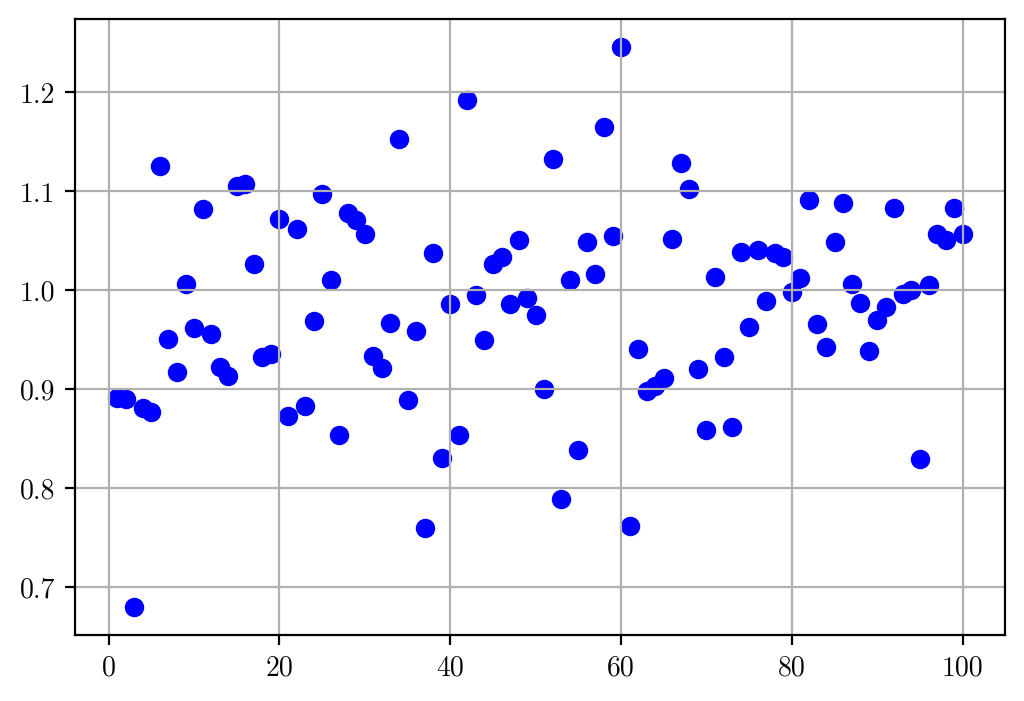

In [46]:
scatter(x, y)